<font color='blue'>**Description:** This dataset contains detailed records of reported crime incidents, likely from a city-level police department such as Chicago. Each row represents a single crime event and includes information about when and where the incident occurred, the type of offense, and whether an arrest was made. The dataset captures both categorical details—such as the primary crime type, specific description, and location type—and geographic information, including block-level addresses, police districts, community areas, and precise coordinates (latitude and longitude). It also includes standardized classification codes like IUCR and FBI codes, which allow crimes to be categorized consistently for analysis. Overall, this dataset is useful for crime pattern analysis, spatial mapping, trend detection over time, and building predictive or classification models in data science and public safety research.

| **Field Name**           | **Description**                                                                    |
| ------------------------ | ---------------------------------------------------------------------------------- |
| **ID**                   | Unique identifier for each crime record.                                           |
| **Case Number**          | Official police case number assigned to the incident.                              |
| **Date**                 | Date and time when the crime occurred.                                             |
| **Block**                | Approximate address (block-level) where the incident took place.                   |
| **IUCR**                 | Illinois Uniform Crime Reporting code that categorizes the offense.                |
| **Primary Type**         | Main category of the crime (e.g., THEFT, ROBBERY, NARCOTICS).                      |
| **Description**          | More detailed explanation of the crime type.                                       |
| **Location Description** | Type of location where the crime occurred (e.g., STREET, RESIDENCE, BANK).         |
| **Arrest**               | Indicates whether an arrest was made (`TRUE` or `FALSE`).                          |
| **Domestic**             | Indicates whether the incident was domestic-related (`TRUE` or `FALSE`).           |
| **Beat**                 | Police beat (smallest geographic policing unit) where the crime occurred.          |
| **District**             | Police district number covering the area of the incident.                          |
| **Ward**                 | City council ward where the incident occurred.                                     |
| **Community Area**       | Chicago community area number representing a specific neighborhood region.         |
| **FBI Code**             | Crime classification code used by the FBI’s Uniform Crime Reporting system.        |
| **X Coordinate**         | X coordinate in the Illinois State Plane coordinate system (east-west position).   |
| **Y Coordinate**         | Y coordinate in the Illinois State Plane coordinate system (north-south position). |
| **Year**                 | Year when the crime occurred.                                                      |
| **Updated On**           | Date and time when the record was last updated.                                    |
| **Latitude**             | Geographic latitude of the crime location.                                         |
| **Longitude**            | Geographic longitude of the crime location.                                        |
| **Location**             | Combined latitude and longitude in a single field (point format).                  |


**Web Address:** https://data.cityofchicago.org/Public-Safety/City-of-Chicago-Crime-Data/v9q9-3dm2?category=Public-Safety&view_name=City-of-Chicago-Crime-Data

**API link to access:** https://data.cityofchicago.org/api/v3/views/ijzp-q8t2/query.json

## **1. Exploratory Data Analysis**

**1.1. Import necessary libraries**

In [ ]:
# import pandas library for data manipulation and working with DataFrames
import pandas as pd

# import Google Drive module to access files stored in your Drive (only used in Google Colab)
from google.colab import drive

# import matplotlib for creating plots and visualizations (like histograms, boxplots, etc.)
import matplotlib.pyplot as plt

**Read from the API and save into a CSV file in the google Drive**

In [ ]:
#Read all data 100000 by 100000 chunks from API and store in a dataframe
# create an empty list to store each chunk of data
chunks = []

# number of rows to load per request (100,000 rows each time)
limit = 100000

# starting point for data retrieval (pagination offset)
offset = 0

# loop to continuously fetch data in chunks
while True:

    # construct API URL with limit and offset to get different portions of data
    url = f"https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$limit={limit}&$offset={offset}"

    # read a chunk of data from the API
    chunk = pd.read_csv(url)

    # if no data is returned, stop the loop (end of dataset)
    if chunk.empty:
        break

    # print number of rows loaded in this chunk (for tracking progress)
    print(f"Loaded {len(chunk)} rows...")

    # store the chunk in the list
    chunks.append(chunk)

    # move to the next set of rows
    offset += limit

# combine all chunks into one DataFrame
df = pd.concat(chunks, ignore_index=True)

# print final size of the dataset (rows, columns)
print("Final shape:", df.shape)

Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100000 rows...
Loaded 100

In [ ]:
#Connect to Google drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#save data in the Google drive
df.to_csv("/content/drive/MyDrive/crime_data.csv", index=False)

**1.2. Load the Dataset**

In [ ]:
#Read data from google drive
df = pd.read_csv("/content/drive/MyDrive/crime_data.csv")

#Print first 5 rows of this dataframe
print(df.head())

#Print the shape of this
print(df.shape)

         id case_number                     date                      block  \
0  14167889    JK218731  2026-04-15T00:00:00.000       071XX S JEFFERY BLVD   
1  14168892    JK220034  2026-04-15T00:00:00.000          003XX W GRAND AVE   
2  14167483    JK218247  2026-04-15T00:00:00.000         029XX N PULASKI RD   
3  14168138    JK218899  2026-04-15T00:00:00.000  062XX S COTTAGE GROVE AVE   
4  14168001    JK218845  2026-04-15T00:00:00.000         036XX N CICERO AVE   

   iucr                primary_type                          description  \
0  0560                     ASSAULT                               SIMPLE   
1  1365           CRIMINAL TRESPASS                         TO RESIDENCE   
2  1310             CRIMINAL DAMAGE                          TO PROPERTY   
3  1750  OFFENSE INVOLVING CHILDREN                          CHILD ABUSE   
4  0430                     BATTERY  AGGRAVATED - OTHER DANGEROUS WEAPON   

           location_description  arrest  domestic  ...  ward  commun

In [ ]:
#Create a copy of the original dataframe to perform preprocessing
df_process=df.copy()

**1.2. Handdling misssing values**

In [ ]:
#Print number of null and missing values for each field
df_process.isnull().sum()

,0
id,0
case_number,0
date,0
block,0
iucr,0
primary_type,0
description,0
location_description,15914
arrest,0
domestic,0


<font color='blue'>**Description:**
Since we need to work on the crime count at the weekly time steps and date does not have any missing values. Therefore, we do not delete any records and continue the EDA process.

**1.3. Feature engineering**

In [ ]:
#Keep only required columns
df_process = df_process[["date", "primary_type"]]

In [ ]:
#Print data types of all fields
df_process.dtypes

,0
date,object
primary_type,object


In [ ]:
#Convert data of date field to datetime format for further processing
df_process["date"] = pd.to_datetime(df["date"], errors="coerce")

# remove rows with invalid dates
df = df.dropna(subset=["date"])


In [ ]:
# this converts each date to the start of its week
weeks = df_process["date"].dt.to_period("W")

#Add a week column to the dataframe for modeling as timesteps
df_process["week"] = weeks.dt.start_time

In [ ]:
#Generate weekly dataframe by fining weekly count for modeling
df_weekly = df_process.groupby("week").size().reset_index(name="crime_count")

In [ ]:
#Print the first 1000 records of the weekly dataframe
df_weekly.head(1000)

,week,crime_count
0,2001-01-01,8957
1,2001-01-08,8589
2,2001-01-15,8705
3,2001-01-22,8301
4,2001-01-29,8479
...,...,...
995,2020-01-27,4822
996,2020-02-03,4474
997,2020-02-10,4258
998,2020-02-17,4472


**1.4. Statistical Analysis**

In [ ]:
#print basic statistics for week column
df_weekly.describe()

,week,crime_count
count,1320,1320.000000
mean,2013-08-22 12:00:00,6467.593182
min,2001-01-01 00:00:00,1185.000000
25%,2007-04-28 06:00:00,4888.000000
50%,2013-08-22 12:00:00,5815.500000
75%,2019-12-17 18:00:00,8226.500000
max,2026-04-13 00:00:00,10613.000000
std,NaN,1913.830437


<font color='blue'>**Description:** The descriptive statistics of the weekly crime counts show that the dataset contains 1,319 weeks of observations, indicating a long-term time series spanning multiple years. On average, there are approximately 6,471 crimes per week, which represents the typical level of crime activity in the dataset. The minimum weekly crime count is 2,827, while the maximum reaches 10,613, showing that crime levels vary substantially across different weeks.

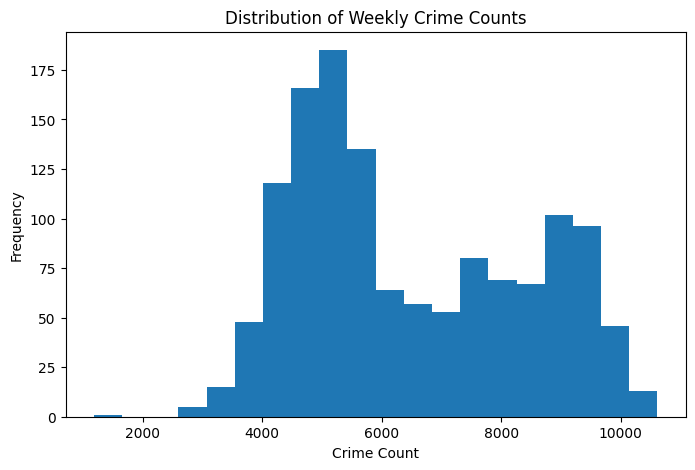

In [ ]:
# create a new figure with specified size (width=8, height=5)
plt.figure(figsize=(8,5))

# plot histogram of weekly crime counts with 20 bins (groups)
plt.hist(df_weekly["crime_count"], bins=20)

# set the title of the plot
plt.title("Distribution of Weekly Crime Counts")

# label for x-axis (crime values)
plt.xlabel("Crime Count")

# label for y-axis (how many weeks fall into each bin)
plt.ylabel("Frequency")

# display the plot
plt.show()

<font color='blue'>**Description:** The histogram illustrates the distribution of weekly crime counts over the observed period. The data does not follow a perfectly normal (bell-shaped) distribution; instead, it shows a slightly bimodal pattern, meaning there appear to be two common ranges where crime counts frequently occur.
The first concentration of values is around 4,500 to 6,000 crimes per week, indicating many weeks fall into a moderate crime level. A second noticeable peak occurs around 8,000 to 9,500 crimes per week, suggesting another cluster of higher crime activity. This pattern may reflect changes over time, such as differences between earlier and later years, seasonal effects, or policy and social changes.

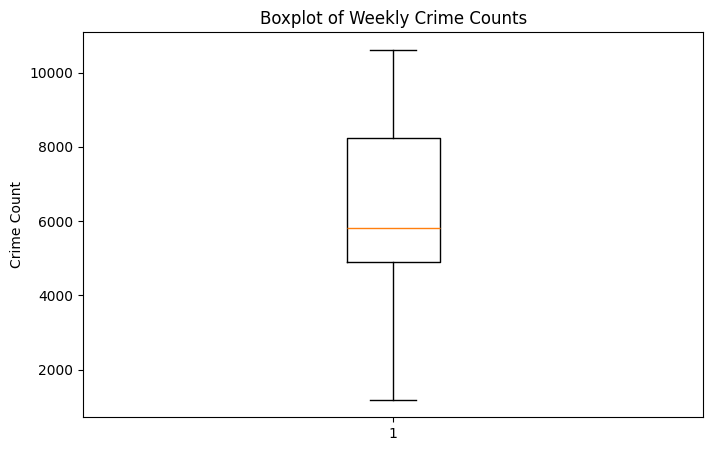

In [ ]:
# create a new figure with specified size (width=8, height=5)
plt.figure(figsize=(8,5))

# create a boxplot for the weekly crime counts
# this shows median, quartiles, and potential outliers
plt.boxplot(df_weekly["crime_count"])

# set the title of the plot
plt.title("Boxplot of Weekly Crime Counts")

# label for y-axis (crime values)
plt.ylabel("Crime Count")

# display the plot
plt.show()

<font color='blue'>**Description:**
The boxplot summarizes the distribution of weekly crime counts by highlighting the central tendency, spread, and variability of the data. The median crime count is approximately 5,800 crimes per week, which represents the typical weekly level of crime. The box (interquartile range) extends from about 4,900 (25th percentile) to 8,200 (75th percentile), indicating that the middle 50% of the weeks fall within this range.
The whiskers show the overall spread of the data, with the minimum around 2,800 crimes and the maximum near 10,600 crimes, demonstrating a wide variation in crime levels across weeks. This confirms that crime is not constant over time and can fluctuate significantly.
The box appears slightly skewed upward (right-skewed), as the upper range (toward higher crime counts) is more extended than the lower range. This suggests that while most weeks have moderate crime levels, there are several weeks with unusually high crime counts. However, there are no extreme outliers explicitly shown as separate points, indicating that most values fall within a reasonable range.

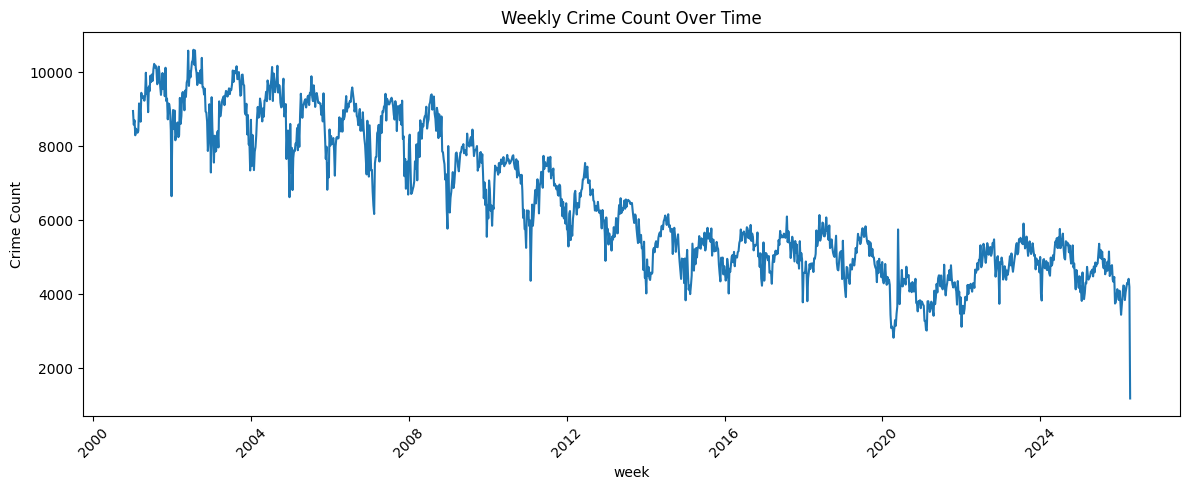

In [ ]:
# make sure Week column is datetime
df_weekly["week"] = pd.to_datetime(df_weekly["week"])

# plot time series
plt.figure(figsize=(12,5))
plt.plot(df_weekly["week"], df_weekly["crime_count"])

# titles and labels
plt.title("Weekly Crime Count Over Time")
plt.xlabel("week")
plt.ylabel("Crime Count")

plt.xticks(rotation=45)  # rotate dates for better visibility
plt.tight_layout()

plt.show()

<font color='blue'>**Description:**
The time series plot of weekly crime counts reveals a clear long-term downward trend in crime over the observed period. In the early 2000s, crime levels were relatively high, often ranging between 8,500 and 10,500 incidents per week. Over time, there is a steady decline, particularly noticeable after around 2008–2010, where weekly counts begin to drop more consistently. By the mid-2010s and onward, crime levels stabilize at a lower range, generally between 4,000 and 6,000 incidents per week.
In addition to the overall decline, the plot shows a strong seasonal pattern, with regular fluctuations occurring each year—peaks and troughs that likely correspond to seasonal or environmental factors influencing crime rates. There are also a few noticeable sharp drops and spikes, which may reflect unusual events or disruptions, such as policy changes or external factors. Notably, around 2020, there is a significant dip, possibly associated with major societal changes during that period.

**1.5. Extracting the final clead dataset for machine learning model**

In [ ]:
# save the weekly crime DataFrame to a CSV file (without including the index column)
df_weekly.to_csv("weekly_crime.csv", index=False)

## **2. Model Development**

**2.1. Import neccessary libraries**

In [ ]:
# Import numerical computing library (used for arrays, math operations)
import numpy as np

# Import pandas for data manipulation and handling datasets (DataFrames)
import pandas as pd

# Import matplotlib for plotting graphs and visualizations
import matplotlib.pyplot as plt

# Import TensorFlow (deep learning framework)
import tensorflow as tf

# Import Sequential model (used to build neural networks layer-by-layer)
from tensorflow.keras.models import Sequential

# Import different neural network layers:
# - SimpleRNN: basic recurrent neural network
# - Bidirectional: processes sequence forward and backward
# - LSTM: handles long-term dependencies better than RNN
# - GRU: similar to LSTM but simpler and faster
# - Dense: fully connected layer (output layer)
from tensorflow.keras.layers import SimpleRNN, Bidirectional, LSTM, GRU, Dense

# Import Adam optimizer (used to update model weights during training)
from tensorflow.keras.optimizers import Adam

**2.2. Load the dataset**

In [ ]:
# Load the dataset from CSV file into a pandas DataFrame
df_weekly = pd.read_csv("weekly_crime.csv")

# Convert the 'week' column to datetime format (important for time-series handling)
df_weekly["week"] = pd.to_datetime(df_weekly["week"])

# Extract the crime count column as a NumPy array (convert to float for modeling)
data = df_weekly["crime_count"].values.astype(float)

# Extract the corresponding week values (used later for plotting or alignment)
weeks = df_weekly["week"].values

**2.3. Normalizing data**

In [ ]:
# Calculate the mean (average) of the data
mean_v = data.mean()

# Calculate the standard deviation (spread) of the data
std_v  = data.std()

# Normalize the data using z-score normalization:
# (value - mean) / standard deviation
# This centers the data around 0 and scales it to unit variance
data_norm = (data - mean_v) / std_v

**2.4. Defining Sliding window**

In [ ]:
# Define the sequence length (number of past time steps used as input)
SEQ_LEN = 500

# Function to create input-output sequences for time series modeling
def create_sequences(d, seq_len):
    X, y = [], []

    # Loop through the dataset to create sliding windows
    for i in range(len(d) - seq_len):

        # Input: sequence of 'seq_len' consecutive values
        X.append(d[i:i+seq_len])

        # Output: the next value after the sequence (prediction target)
        y.append(d[i+seq_len])

    # Convert lists to NumPy arrays for model compatibility
    return np.array(X), np.array(y)

# Apply the function to normalized data to generate training sequences
X, y = create_sequences(data_norm, SEQ_LEN)

**2.5. Split the dataset into Train and test sets**

In [ ]:
# Calculate the split index (80% for training, 20% for testing)
split = int(len(X) * 0.8)

# Split input sequences into training and testing sets
X_train, X_test = X[:split], X[split:]

# Split corresponding target values into training and testing sets
y_train, y_test = y[:split], y[split:]

In [ ]:
# Reshape training data to 3D format required by RNN models:
# (samples, time steps, features)
# Here, features = 1 because we have a single time-series variable
X_train_rnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

# Reshape test data in the same way for consistency
X_test_rnn  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

**2.6. Defining the Hyperparameters for all models**

In [ ]:
# Set a random seed for reproducibility
# This ensures you get the same results each time you run the code
np.random.seed(42)

# Number of hidden units (neurons) in the RNN/LSTM/GRU layer
H = 32

# Number of times the model will iterate over the entire training dataset
EPOCHS = 50

# Learning rate for the optimizer (controls how fast the model learns)
LR = 0.001

# Number of samples processed before updating the model weights
BATCH = 16

**2.7. Defining the Evaluation Metrics**

In [ ]:
# Root Mean Squared Error (RMSE)
# Measures the square root of average squared differences between predictions and true values
# Lower RMSE = better performance
def rmse(pred, true):
    # Convert normalized error back to original scale using std_v
    return np.sqrt(np.mean(((pred - true) * std_v) ** 2))


# Mean Absolute Error (MAE)
# Measures the average absolute difference between predictions and true values
# Lower MAE = better performance
def mae(pred, true):
    # Convert normalized error back to original scale using std_v
    return np.mean(np.abs((pred - true) * std_v))


# Mean Absolute Percentage Error (MAPE)
# Measures error as a percentage of actual values
# Lower MAPE = better performance
def mape(pred, true):
    # Convert normalized values back to original scale
    actual    = true * std_v + mean_v
    predicted = pred * std_v + mean_v

    # Compute percentage error
    return np.mean(np.abs((actual - predicted) / actual)) * 100


# R-squared (R² Score)
# Measures how well predictions explain the variance in the data
# Closer to 1 = better fit, 0 = no improvement over mean, negative = poor model
def r2_score_custom(pred, true):
    # Convert normalized values back to original scale
    actual = true * std_v + mean_v
    predicted = pred * std_v + mean_v

    # Residual sum of squares (error)
    ss_res = np.sum((actual - predicted) ** 2)

    # Total sum of squares (variance of actual data)
    ss_tot = np.sum((actual - actual.mean()) ** 2)

    # Compute R² score
    return 1 - (ss_res / ss_tot)

In [ ]:
# Initialize a dictionary to store evaluation metrics for each model
# Each key will be the model name (e.g., "RNN", "LSTM")
# Each value will be a list of metrics [RMSE, MAE, MAPE, R2]
metrics = {}

## **3. Model Development**

**3.1. Vanilla Recurrent Neural Network**

In [ ]:
# Build the Vanilla RNN model
model_rnn = Sequential([
    # SimpleRNN layer with H hidden units
    # input_shape = (time steps, features)
    SimpleRNN(H, input_shape=(SEQ_LEN, 1), activation='tanh'),

    # Dense output layer to predict a single value (next time step)
    Dense(1)
])

# Compile the model
# Adam optimizer with defined learning rate
# Mean Squared Error (MSE) as loss function
model_rnn.compile(optimizer=Adam(learning_rate=LR), loss='mse')

# Train the model
history_rnn = model_rnn.fit(
    X_train_rnn, y_train,      # Training data
    epochs=EPOCHS,             # Number of training iterations
    batch_size=BATCH,          # Number of samples per update
    validation_split=0.1,      # Use 10% of training data for validation
    verbose=1                  # Show training progress
)

# Generate predictions on the test set
rnn_preds = model_rnn.predict(X_test_rnn).flatten()

# Compute evaluation metrics
rnn_rmse = rmse(rnn_preds, y_test)   # Root Mean Squared Error
rnn_mae  = mae(rnn_preds, y_test)    # Mean Absolute Error
rnn_mape = mape(rnn_preds, y_test)   # Mean Absolute Percentage Error
rnn_r2   = r2_score_custom(rnn_preds, y_test)  # R² score

# Store metrics in dictionary under "RNN"
metrics["RNN"] = [rnn_rmse, rnn_mae, rnn_mape, rnn_r2]

# Print the results
print(metrics["RNN"])

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0686 - val_loss: 0.0382
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0414 - val_loss: 0.0354
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0372 - val_loss: 0.0331
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0336 - val_loss: 0.0296
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0319 - val_loss: 0.0348
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0322 - val_loss: 0.0269
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0333 - val_loss: 0.0256
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0284 - val_loss: 0.0258
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0279 - val_loss: 0.0262
Epoch 10/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 0.0276 - val_loss: 0.0248
Epoch 11/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0278 - val_loss: 0.0247
Epoch 12/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0282 - val_

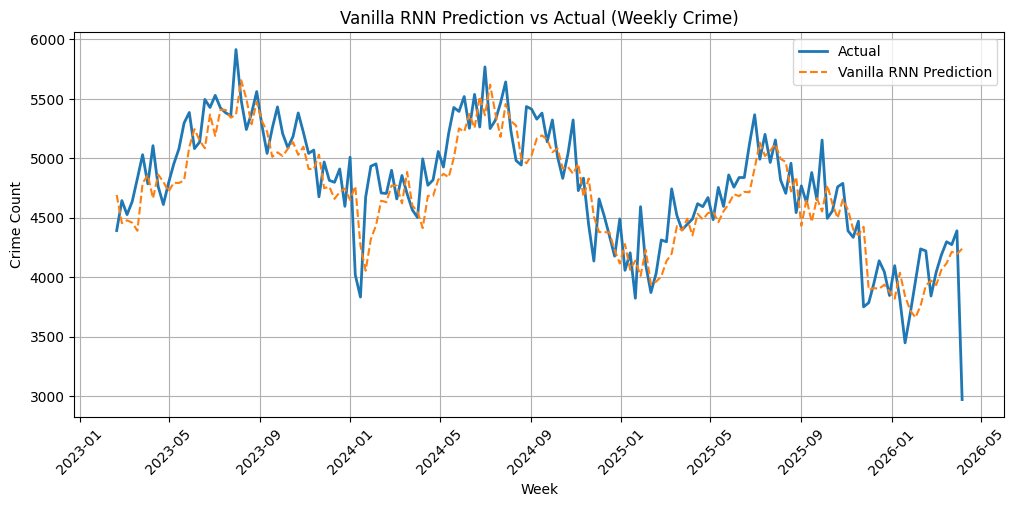

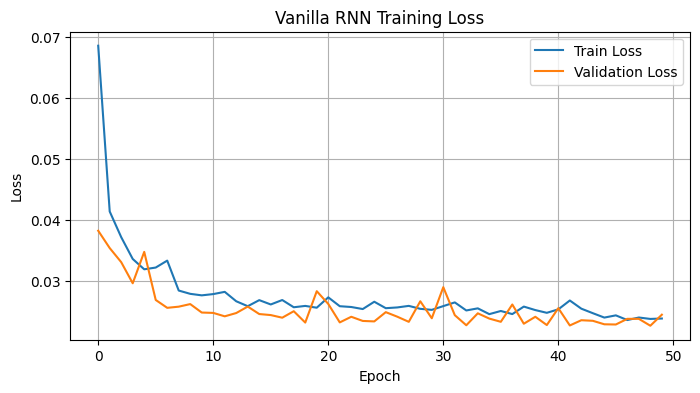

In [ ]:
# =============================
# TEST WEEKS
# =============================
test_weeks = weeks[SEQ_LEN + split:]

# =============================
# DENORMALIZATION FUNCTION
# =============================
def denorm(x):
    return np.array(x) * std_v + mean_v

y_test_denorm = denorm(y_test)
rnn_preds_denorm = denorm(rnn_preds)

# =============================
# PLOT: ACTUAL vs PREDICTED
# =============================
plt.figure(figsize=(12,5))

plt.plot(test_weeks, y_test_denorm, label="Actual", linewidth=2)
plt.plot(test_weeks, rnn_preds_denorm, label="Vanilla RNN Prediction", linestyle='--')

plt.title("Vanilla RNN Prediction vs Actual (Weekly Crime)")
plt.xlabel("Week")
plt.ylabel("Crime Count")
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.show()

# =============================
# PLOT: TRAINING LOSS
# =============================
plt.figure(figsize=(8,4))

plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.title("Vanilla RNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

**3.2. Bidirectional Recurrent Neural Network**

In [ ]:
# Build the Bidirectional RNN model
model_birnn = Sequential([
    # Bidirectional wrapper allows the RNN to process the sequence
    # both forward (past → future) and backward (future → past)
    Bidirectional(SimpleRNN(H, activation='tanh'), input_shape=(SEQ_LEN, 1)),

    # Dense output layer to predict a single value
    Dense(1)
])

# Compile the model
# Adam optimizer with specified learning rate
# Mean Squared Error (MSE) as the loss function
model_birnn.compile(optimizer=Adam(learning_rate=LR), loss='mse')

# Train the model
history_birnn = model_birnn.fit(
    X_train_rnn, y_train,      # Training data
    epochs=EPOCHS,             # Number of training iterations
    batch_size=BATCH,          # Number of samples per update
    validation_split=0.1,      # Use 10% of training data for validation
    verbose=1                  # Display training progress
)

# Generate predictions on the test set
birnn_preds = model_birnn.predict(X_test_rnn).flatten()

# Compute evaluation metrics
birnn_rmse = rmse(birnn_preds, y_test)   # Root Mean Squared Error
birnn_mae  = mae(birnn_preds, y_test)    # Mean Absolute Error
birnn_mape = mape(birnn_preds, y_test)   # Mean Absolute Percentage Error
birnn_r2   = r2_score_custom(birnn_preds, y_test)  # R² score

# Store metrics in dictionary under "BiRNN"
metrics["BiRNN"] = [birnn_rmse, birnn_mae, birnn_mape, birnn_r2]

# Print the results
print(metrics["BiRNN"])

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - loss: 0.1329 - val_loss: 0.0497
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 0.0430 - val_loss: 0.0380
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0358 - val_loss: 0.0401
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - loss: 0.0325 - val_loss: 0.0319
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - loss: 0.0297 - val_loss: 0.0314
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - loss: 0.0291 - val_loss: 0.0309
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0275 - val_loss: 0.0284
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - loss: 0.0282 - val_loss: 0.0285
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.0267 - val_loss: 0.0239
Epoch 10/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - loss: 0.0273 - val_loss: 0.0223
Epoch 11/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.0251 - val_loss: 0.0260
Epoch 12/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0

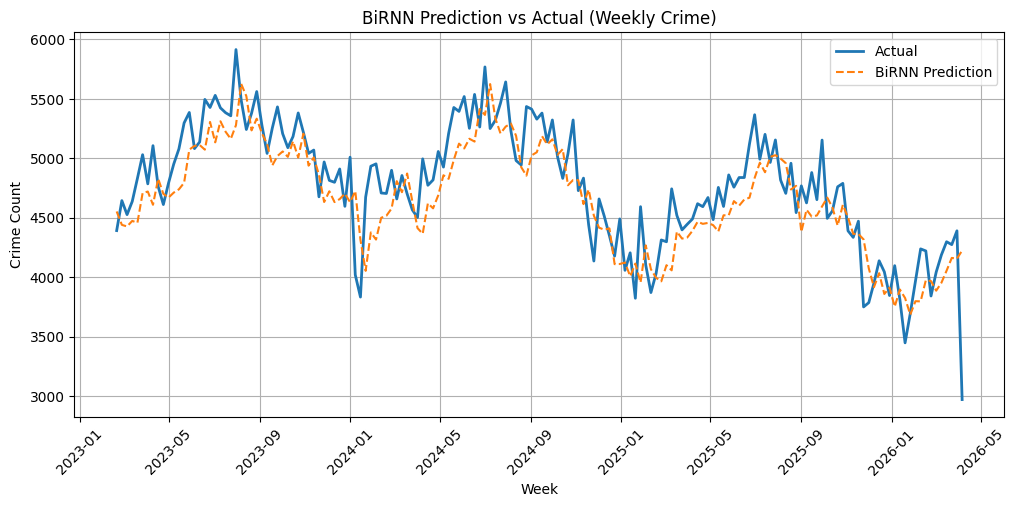

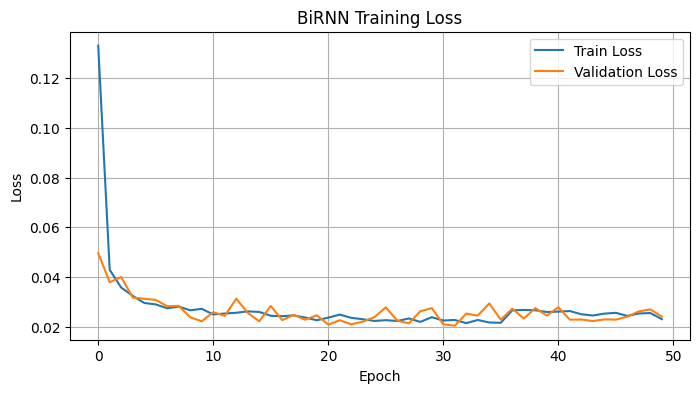

In [ ]:
# =============================
# TEST WEEKS
# =============================
test_weeks = weeks[SEQ_LEN + split:]

# =============================
# DENORMALIZATION FUNCTION
# =============================
def denorm(x):
    return np.array(x) * std_v + mean_v

y_test_denorm = denorm(y_test)
birnn_preds_denorm = denorm(birnn_preds)

# =============================
# PLOT: ACTUAL vs PREDICTED
# =============================
plt.figure(figsize=(12,5))

plt.plot(test_weeks, y_test_denorm, label="Actual", linewidth=2)
plt.plot(test_weeks, birnn_preds_denorm, label="BiRNN Prediction", linestyle='--')

plt.title("BiRNN Prediction vs Actual (Weekly Crime)")
plt.xlabel("Week")
plt.ylabel("Crime Count")
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.show()

# =============================
# PLOT: TRAINING LOSS
# =============================
plt.figure(figsize=(8,4))

plt.plot(history_birnn.history['loss'], label='Train Loss')
plt.plot(history_birnn.history['val_loss'], label='Validation Loss')

plt.title("BiRNN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

**3.3. Long Short term Memory Model**

In [ ]:
# Build the LSTM model
model_lstm = Sequential([
    # LSTM layer with H hidden units
    # Designed to capture long-term dependencies in time series data
    # input_shape = (time steps, features)
    LSTM(H, input_shape=(SEQ_LEN, 1), activation='tanh'),

    # Dense output layer to predict a single value (next time step)
    Dense(1)
])

# Compile the model
# Adam optimizer with specified learning rate
# Mean Squared Error (MSE) as the loss function
model_lstm.compile(optimizer=Adam(learning_rate=LR), loss='mse')

# Train the model
history_lstm = model_lstm.fit(
    X_train_rnn, y_train,      # Training data
    epochs=EPOCHS,             # Number of training iterations
    batch_size=BATCH,          # Number of samples per update
    validation_split=0.1,      # Use 10% of training data for validation
    verbose=1                  # Display training progress
)

# Generate predictions on the test set
lstm_preds = model_lstm.predict(X_test_rnn).flatten()

# Compute evaluation metrics
lstm_rmse = rmse(lstm_preds, y_test)   # Root Mean Squared Error
lstm_mae  = mae(lstm_preds, y_test)    # Mean Absolute Error
lstm_mape = mape(lstm_preds, y_test)   # Mean Absolute Percentage Error
lstm_r2   = r2_score_custom(lstm_preds, y_test)  # R² score

# Store metrics in dictionary under "LSTM"
metrics["LSTM"] = [lstm_rmse, lstm_mae, lstm_mape, lstm_r2]

# Print the results
print(metrics["LSTM"])

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - loss: 0.1249 - val_loss: 0.0407
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - loss: 0.0488 - val_loss: 0.0332
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 146ms/step - loss: 0.0417 - val_loss: 0.0316
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - loss: 0.0383 - val_loss: 0.0268
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - loss: 0.0349 - val_loss: 0.0262
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 154ms/step - loss: 0.0329 - val_loss: 0.0244
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - loss: 0.0329 - val_loss: 0.0320
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - loss: 0.0309 - val_loss: 0.0249
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - loss: 0.0298 - val_loss: 0.0240
Epoch 10/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - loss: 0.0297 - val_loss: 0.0261
Epoch 11/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - loss: 0.0301 - val_loss: 0.0238
Epoch 12/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/ste

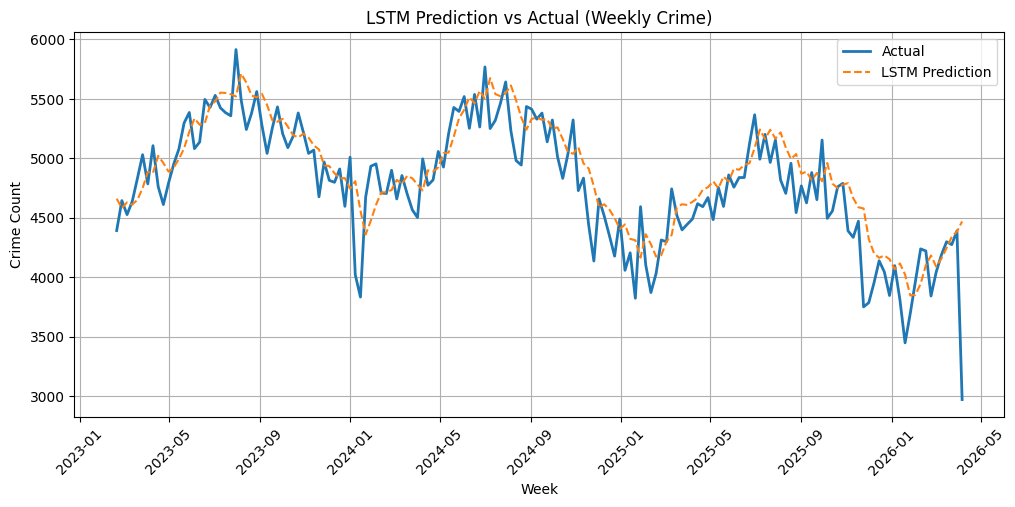

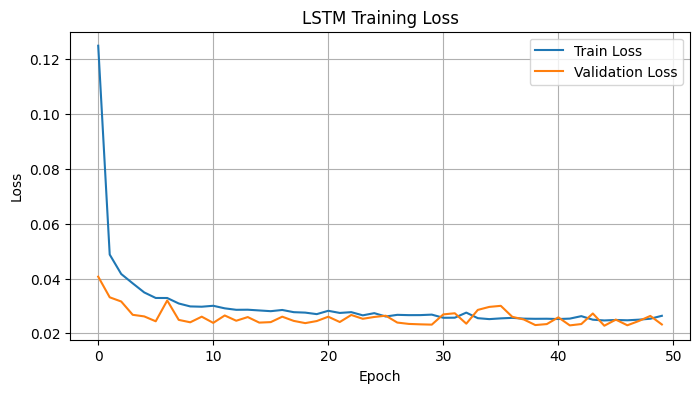

In [ ]:
test_weeks = weeks[SEQ_LEN + split:]
# DENORMALIZATION FUNCTION
# =============================
def denorm(x):
    return np.array(x) * std_v + mean_v

y_test_denorm = denorm(y_test)
lstm_preds_denorm = denorm(lstm_preds)

# =============================
# PLOT: ACTUAL vs PREDICTED
# =============================
plt.figure(figsize=(12,5))

plt.plot(test_weeks, y_test_denorm, label="Actual", linewidth=2)
plt.plot(test_weeks, lstm_preds_denorm, label="LSTM Prediction", linestyle='--')

plt.title("LSTM Prediction vs Actual (Weekly Crime)")
plt.xlabel("Week")
plt.ylabel("Crime Count")
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.show()

# =============================
# PLOT: TRAINING LOSS
# =============================
plt.figure(figsize=(8,4))

plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

**3.4. Gated Recurrent Unit Model**

In [ ]:
# Build the GRU model
model_gru = Sequential([
    # GRU (Gated Recurrent Unit) layer with H hidden units
    # Similar to LSTM but simpler and faster, designed to capture sequence patterns
    # input_shape = (time steps, features)
    GRU(H, input_shape=(SEQ_LEN, 1), activation='tanh'),

    # Dense output layer to predict a single value (next time step)
    Dense(1)
])

# Compile the model
# Adam optimizer with specified learning rate
# Mean Squared Error (MSE) as the loss function
model_gru.compile(optimizer=Adam(learning_rate=LR), loss='mse')

# Train the model
history_gru = model_gru.fit(
    X_train_rnn, y_train,      # Training data
    epochs=EPOCHS,             # Number of training iterations
    batch_size=BATCH,          # Number of samples per update
    validation_split=0.1,      # Use 10% of training data for validation
    verbose=1                  # Display training progress
)

# Generate predictions on the test set
gru_preds = model_gru.predict(X_test_rnn).flatten()

# Compute evaluation metrics
gru_rmse = rmse(gru_preds, y_test)   # Root Mean Squared Error
gru_mae  = mae(gru_preds, y_test)    # Mean Absolute Error
gru_mape = mape(gru_preds, y_test)   # Mean Absolute Percentage Error
gru_r2   = r2_score_custom(gru_preds, y_test)  # R² score

# Store metrics in dictionary under "GRU"
metrics["GRU"] = [gru_rmse, gru_mae, gru_mape, gru_r2]

# Print the results
print(metrics["GRU"])

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 202ms/step - loss: 0.3232 - val_loss: 0.0437
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 211ms/step - loss: 0.0630 - val_loss: 0.0307
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 201ms/step - loss: 0.0385 - val_loss: 0.0257
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 192ms/step - loss: 0.0332 - val_loss: 0.0253
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 212ms/step - loss: 0.0319 - val_loss: 0.0258
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 193ms/step - loss: 0.0308 - val_loss: 0.0255
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - loss: 0.0308 - val_loss: 0.0251
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 211ms/step - loss: 0.0305 - val_loss: 0.0253
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 193ms/step - loss: 0.0301 - val_loss: 0.0252
Epoch 10/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 200ms/step - loss: 0.0297 - val_loss: 0.0245
Epoch 11/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 217ms/step - loss: 0.0295 - val_loss: 0.0250
Epoch 12/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 195ms

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
[np.float64(277.8887465734838), np.float64(218.59795225746387), np.float64(4.720703190733526), np.float64(0.7022300801271185)]


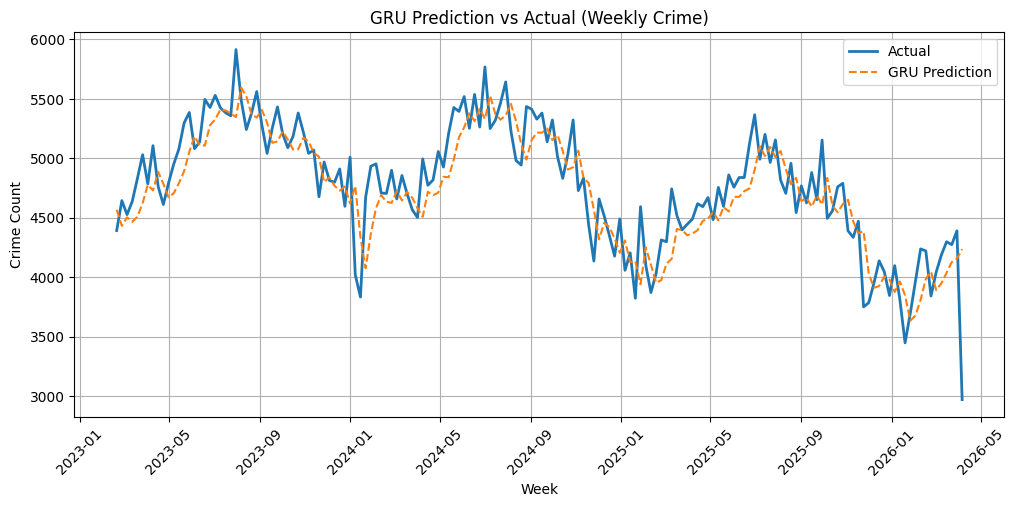

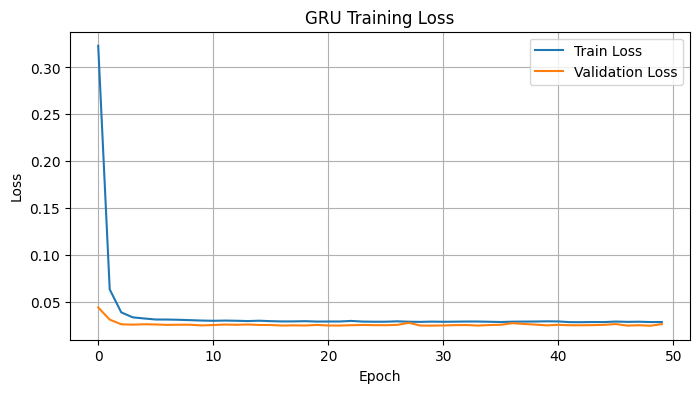

In [ ]:
# =============================
# TEST WEEKS
# =============================
test_weeks = weeks[SEQ_LEN + split:]

# =============================
# DENORMALIZATION FUNCTION
# =============================
def denorm(x):
    return np.array(x) * std_v + mean_v

y_test_denorm = denorm(y_test)
gru_preds_denorm = denorm(gru_preds)

# =============================
# PLOT: ACTUAL vs PREDICTED
# =============================
plt.figure(figsize=(12,5))

plt.plot(test_weeks, y_test_denorm, label="Actual", linewidth=2)
plt.plot(test_weeks, gru_preds_denorm, label="GRU Prediction", linestyle='--')

plt.title("GRU Prediction vs Actual (Weekly Crime)")
plt.xlabel("Week")
plt.ylabel("Crime Count")
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.show()

# =============================
# PLOT: TRAINING LOSS
# =============================
plt.figure(figsize=(8,4))

plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')

plt.title("GRU Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

**3.5. ARIMA Model**

ARIMA (AutoRegressive Integrated Moving Average) is a classical statistical forecasting method. Here we implement an **AR(10) model on the first-differenced series** (d=1) using ordinary least-squares regression, which replicates the core ARIMA(10,1,0) structure without external libraries.

**Differencing** removes the long-term downward trend visible in the EDA, making the series stationary — a prerequisite for AR modelling.

In [ ]:
# Import least squares solver for linear regression (used to estimate AR coefficients)
from numpy.linalg import lstsq

# Apply first-order differencing to make the time series more stationary
# (removes trends by computing difference between consecutive values)
diff1 = np.diff(data_norm)

# Create sliding window sequences on the differenced data
# Xd = input sequences, yd = target values
Xd, yd = create_sequences(diff1, SEQ_LEN)

# Split into training and testing sets (80% train, 20% test)
sp = int(len(Xd) * 0.9)

Xd_train, Xd_test = Xd[:sp], Xd[sp:]
yd_train, yd_test = yd[:sp], yd[sp:]

# Fit AutoRegressive (AR) model using Ordinary Least Squares (OLS)
# This estimates the weights (coefficients) for the AR model
w_ar, _, _, _ = lstsq(Xd_train, yd_train, rcond=None)

# Generate predictions on the test set (in differenced space)
ar_preds_diff = Xd_test @ w_ar

# Undo differencing (integrate back) to return to original normalized scale
# Start from the correct initial values in the original series
start_vals    = data_norm[SEQ_LEN + sp : SEQ_LEN + sp + len(ar_preds_diff)]
ar_preds_orig = start_vals + ar_preds_diff

# Align the true test values with predictions
y_test_ar = data_norm[SEQ_LEN+sp+1 : SEQ_LEN+sp+1+len(ar_preds_diff)]

# Ensure both arrays have the same length (safe comparison)
n = min(len(ar_preds_orig), len(y_test_ar))

# Compute evaluation metrics
arima_rmse = rmse(ar_preds_orig[:n], y_test_ar[:n])   # Root Mean Squared Error
arima_mae  = mae(ar_preds_orig[:n], y_test_ar[:n])    # Mean Absolute Error
arima_mape = mape(ar_preds_orig[:n], y_test_ar[:n])   # Mean Absolute Percentage Error
arima_r2   = r2_score_custom(ar_preds_orig[:n], y_test_ar[:n])  # R² score

# Store metrics in dictionary under "ARIMA"
metrics["ARIMA"] = [arima_rmse, arima_mae, arima_mape, arima_r2]

# Print the results
print(metrics["ARIMA"])

[np.float64(380.7254482760552), np.float64(282.2437652240918), np.float64(6.467281491667368), np.float64(0.3298172952396262)]


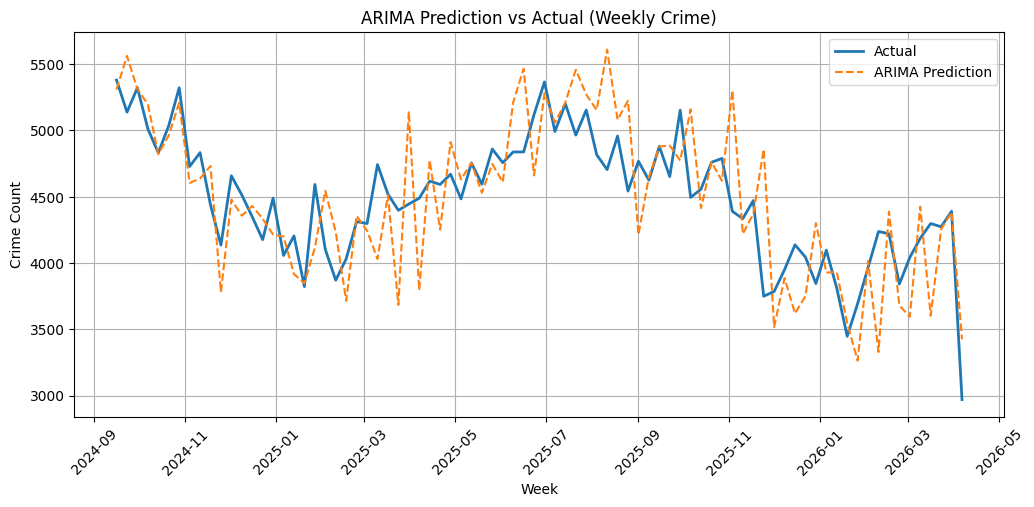

In [ ]:
# =============================
# ALIGN LENGTHS SAFELY
# =============================
n = min(len(ar_preds_orig), len(y_test_ar))

# =============================
# DENORMALIZATION FUNCTION
# =============================
def denorm(x):
    return np.array(x) * std_v + mean_v

y_test_ar_denorm = denorm(y_test_ar[:n])
arima_preds_denorm = denorm(ar_preds_orig[:n])

# =============================
# FIXED DATE ALIGNMENT
# =============================
# Take the last n weeks to match predictions
test_weeks_ar = weeks[-n:]

# =============================
# PLOT: ACTUAL vs PREDICTED
# =============================
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(test_weeks_ar, y_test_ar_denorm, label="Actual", linewidth=2)
plt.plot(test_weeks_ar, arima_preds_denorm, label="ARIMA Prediction", linestyle='--')

plt.title("ARIMA Prediction vs Actual (Weekly Crime)")
plt.xlabel("Week")
plt.ylabel("Crime Count")
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.show()

## **4. Model Evaluation**

**4.1. Comparative metrics Table**

In [ ]:
# Convert the metrics dictionary into a pandas DataFrame
# Rows = models (RNN, LSTM, GRU, etc.)
# Columns = evaluation metrics (RMSE, MAE, MAPE, R2)
metrics_df = pd.DataFrame(metrics, index=["RMSE", "MAE", "MAPE", "R2"]).T

# Display the table of results for all models
print(metrics_df)

             RMSE         MAE      MAPE        R2
RNN    283.060940  219.208526  4.704223  0.691042
BiRNN  299.918707  238.232888  5.069956  0.653147
LSTM   283.407051  211.059216  4.697665  0.690286
GRU    277.888747  218.597952  4.720703  0.702230
ARIMA  380.725448  282.243765  6.467281  0.329817


**4.2. Comparative Bar Chart of the metrics**

In [ ]:

metrics_df = pd.DataFrame(
    metrics,
    index=["RMSE", "MAE", "MAPE", "R2"]
).T

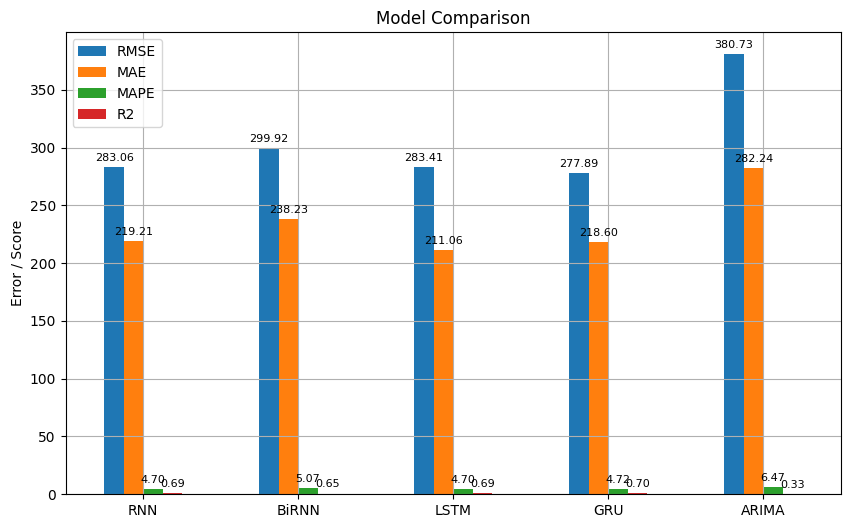

In [ ]:
import matplotlib.pyplot as plt

# Create the bar chart
ax = metrics_df.plot(kind="bar", figsize=(10,6))

# Title and labels
plt.title("Model Comparison")
plt.ylabel("Error / Score")
plt.xticks(rotation=0)
plt.grid(True)

# =============================
# ADD VALUES WITH SMALLER FONT
# =============================
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8)

# Show plot
plt.show()